In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region                  0
Model          

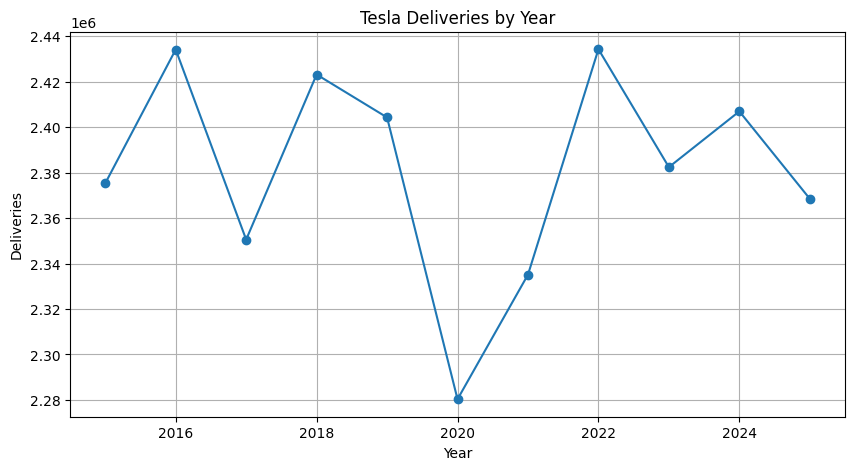

In [6]:
plt.figure(figsize=(10,5))

df.groupby('Year')['Estimated_Deliveries'].sum().plot(marker='o')

plt.title('Tesla Deliveries by Year')
plt.ylabel('Deliveries')
plt.grid(True)

plt.show()

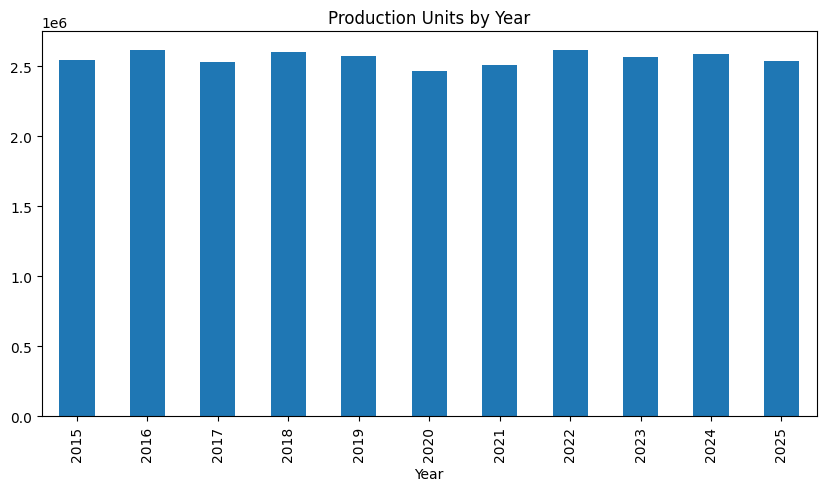

In [7]:
plt.figure(figsize=(10,5))

df.groupby('Year')['Production_Units'].sum().plot(kind='bar')

plt.title('Production Units by Year')

plt.show()

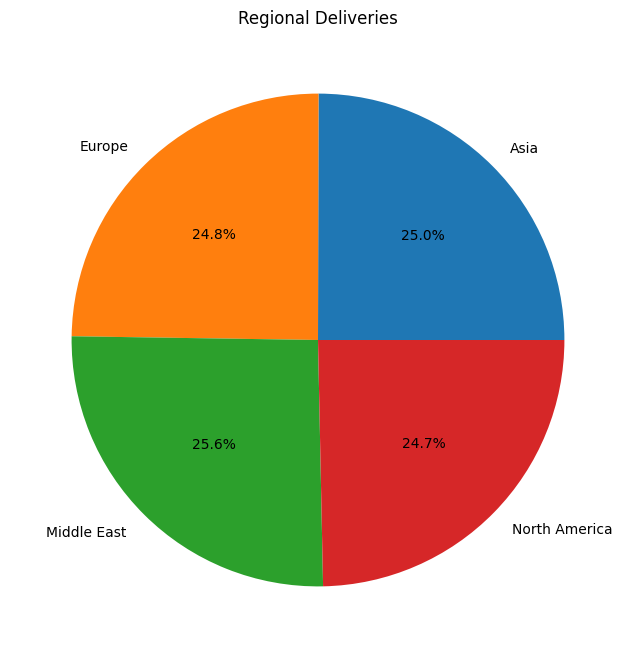

In [8]:
plt.figure(figsize=(8,8))

df.groupby('Region')['Estimated_Deliveries'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Regional Deliveries')

plt.show()

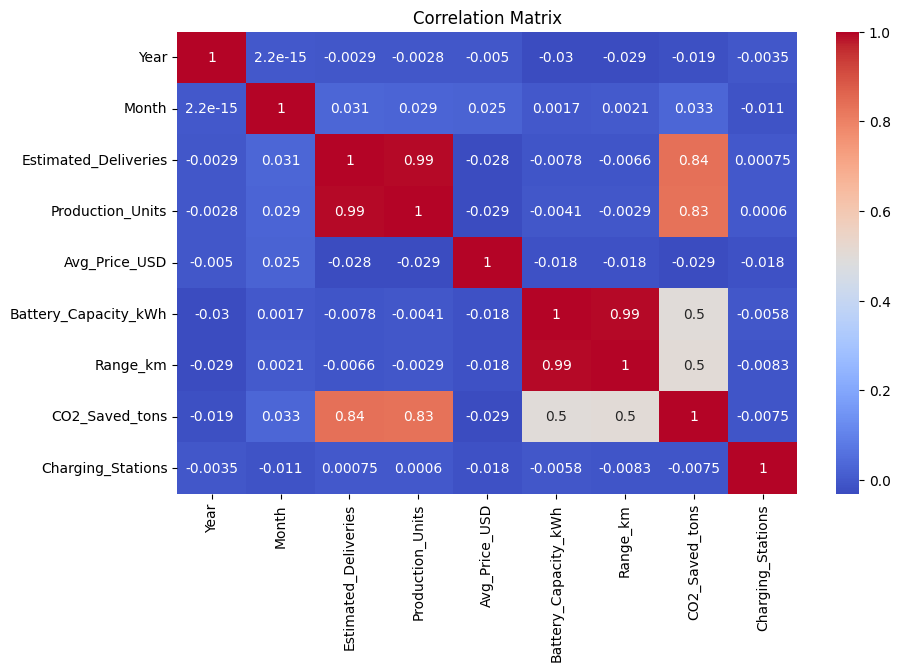

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [10]:
df_ml = df.copy()

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [11]:
X = df_ml.drop('Estimated_Deliveries', axis=1)
y = df_ml['Estimated_Deliveries']

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Success")

Success


In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
predictions = model.predict(X_test)

predictions[:10]

array([ 7361.8 ,  9357.63,  8942.64,  9422.18,  8777.07, 11708.21,
       13988.37, 13923.76, 10180.63,  7877.03])

In [15]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 323.46011363636364
R2 Score: 0.9887505867840798


In [16]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}
Best Score:
0.9881592922379768


In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
4    Production_Units    0.990785
8      CO2_Saved_tons    0.002348
7            Range_km    0.001415
5       Avg_Price_USD    0.001338
10  Charging_Stations    0.001170
0                Year    0.000837
1               Month    0.000758
3               Model    0.000469
2              Region    0.000398
9         Source_Type    0.000321


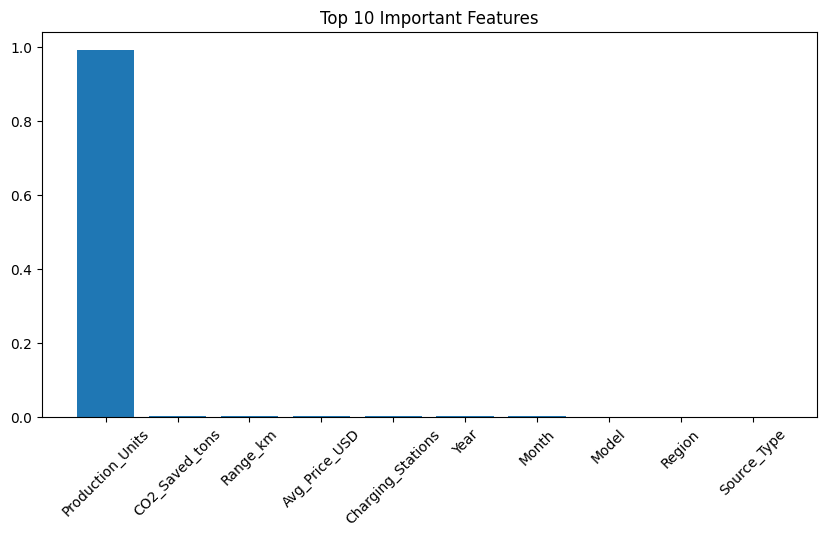

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xticks(rotation=45)

plt.title('Top 10 Important Features')

plt.show()

In [19]:
yearly_data = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

yearly_data['Next_Year_Forecast'] = yearly_data[
    'Estimated_Deliveries'
].rolling(3).mean()

print(yearly_data)

    Year  Estimated_Deliveries  Next_Year_Forecast
0   2015               2375267                 NaN
1   2016               2434081                 NaN
2   2017               2350517        2.386622e+06
3   2018               2423104        2.402567e+06
4   2019               2404230        2.392617e+06
5   2020               2280336        2.369223e+06
6   2021               2335116        2.339894e+06
7   2022               2434220        2.349891e+06
8   2023               2382375        2.383904e+06
9   2024               2406899        2.407831e+06
10  2025               2368462        2.385912e+06


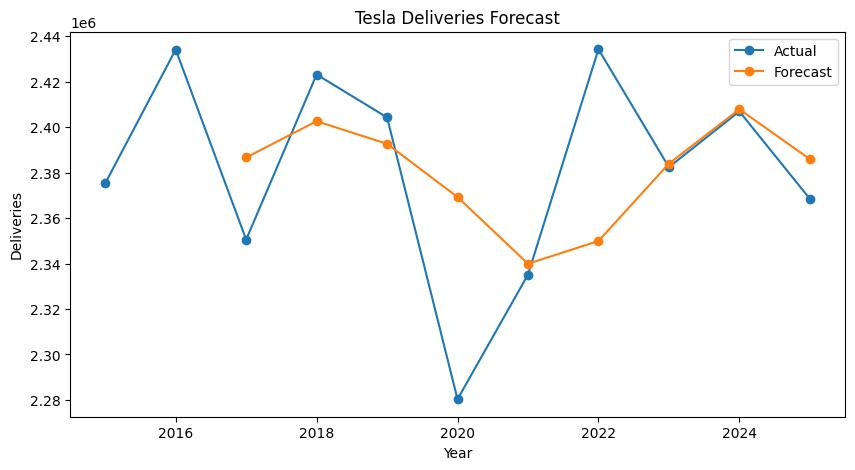

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_data['Year'],
    yearly_data['Estimated_Deliveries'],
    marker='o',
    label='Actual'
)

plt.plot(
    yearly_data['Year'],
    yearly_data['Next_Year_Forecast'],
    marker='o',
    label='Forecast'
)

plt.title('Tesla Deliveries Forecast')

plt.xlabel('Year')
plt.ylabel('Deliveries')

plt.legend()

plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
Year                    0
Month                   0
Region                  0
Model                

In [18]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [24]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
p-value: 0.0
Series is Stationary


DATASET SHAPE
(2640, 12)

DATASET COLUMNS
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

MISSING VALUES
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

DUPLICATES: 0

SUMMARY STATISTICS
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000 

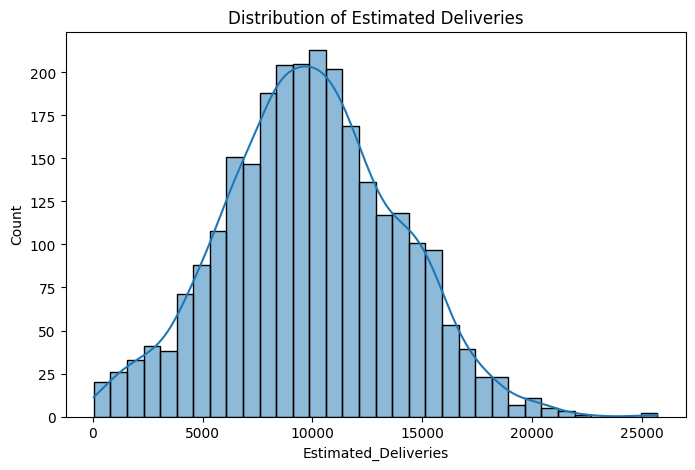

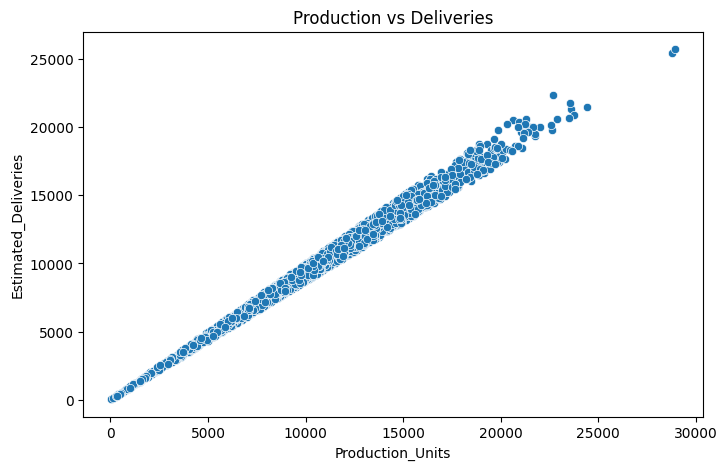

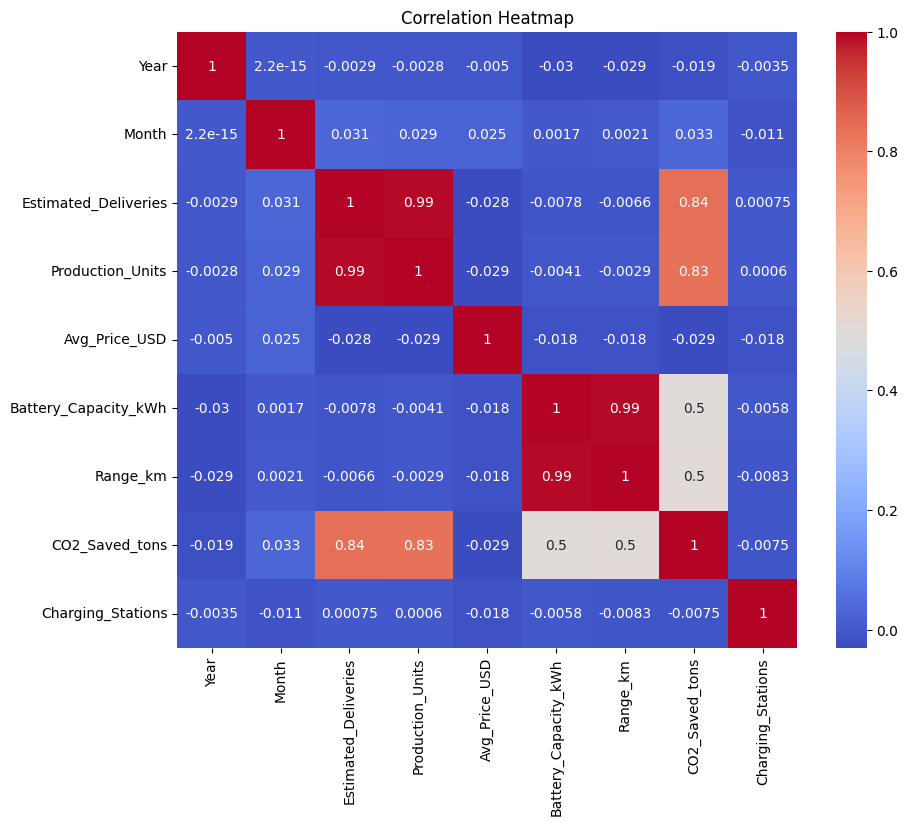


ADF TEST
ADF Statistic: -24.640406918711196
P-Value: 0.0
Series is Stationary

LINEAR REGRESSION R2
1.0

RIDGE R2
0.9995380975393346

LASSO R2
0.9999721734793199

CROSS VALIDATION SCORES
[0.9971037653650491, 0.9985046581046829, 0.9990026959078705, 0.9993342739069057, 0.9995055117328793]
AVERAGE CV SCORE
0.9986901810034775

BEST PARAMETERS
{'ridge__alpha': 0.01}

MAE
0.8429691100042604

RMSE
1.026986287653826

R2 SCORE
0.9999999216087877

TRAIN R2
0.9999999360028246

TEST R2
0.9999999216087877

Model Generalizes Well


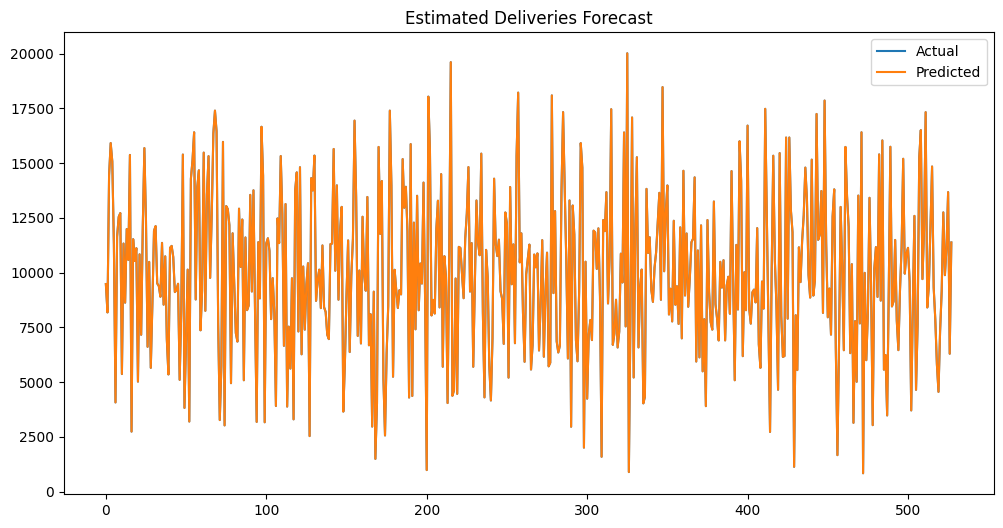


TRAINING SAMPLES: 2110
TESTING SAMPLES: 528
Chronological Split Applied Successfully

PROJECT COMPLETED SUCCESSFULLY


In [4]:
# =========================
# END-TO-END ML PIPELINE
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print("="*50)
print("DATASET SHAPE")
print(df.shape)

print("\nDATASET COLUMNS")
print(df.columns.tolist())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES:", df.duplicated().sum())

# =========================
# DATA CLEANING
# =========================

df.drop_duplicates(inplace=True)

# =========================
# EDA
# =========================

print("\nSUMMARY STATISTICS")
print(df.describe())

plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)
plt.title("Production vs Deliveries")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# ENCODING
# =========================

df = pd.get_dummies(
    df,
    columns=["Region","Model","Source_Type"],
    drop_first=True
)

# =========================
# FEATURE ENGINEERING
# =========================

df = df.sort_values(
    by=["Year","Month"]
)

df["Deliveries_lag1"] = (
    df["Estimated_Deliveries"].shift(1)
)

df["Deliveries_lag2"] = (
    df["Estimated_Deliveries"].shift(2)
)

df["Production_lag1"] = (
    df["Production_Units"].shift(1)
)

df["Deliveries_roll3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df.dropna(inplace=True)

# =========================
# STATIONARITY TEST
# =========================

print("\nADF TEST")

result = adfuller(
    df["Estimated_Deliveries"]
)

print("ADF Statistic:", result[0])
print("P-Value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

# =========================
# FEATURES & TARGET
# =========================

X = df.drop(
    "Estimated_Deliveries",
    axis=1
)

y = df["Estimated_Deliveries"]

# =========================
# CHRONOLOGICAL SPLIT
# =========================

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# =========================
# LINEAR REGRESSION
# =========================

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("\nLINEAR REGRESSION R2")
print(r2_score(y_test, pred_lr))

# =========================
# RIDGE REGRESSION
# =========================

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_pipe.fit(
    X_train,
    y_train
)

pred_ridge = ridge_pipe.predict(
    X_test
)

print("\nRIDGE R2")
print(r2_score(y_test, pred_ridge))

# =========================
# LASSO REGRESSION
# =========================

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1))
])

lasso_pipe.fit(
    X_train,
    y_train
)

pred_lasso = lasso_pipe.predict(
    X_test
)

print("\nLASSO R2")
print(r2_score(y_test, pred_lasso))

# =========================
# CROSS VALIDATION
# =========================

tscv = TimeSeriesSplit(
    n_splits=5
)

scores = []

for train_idx, test_idx in tscv.split(X_train):

    X_cv_train = X_train.iloc[train_idx]
    X_cv_test = X_train.iloc[test_idx]

    y_cv_train = y_train.iloc[train_idx]
    y_cv_test = y_train.iloc[test_idx]

    ridge_pipe.fit(
        X_cv_train,
        y_cv_train
    )

    pred_cv = ridge_pipe.predict(
        X_cv_test
    )

    scores.append(
        r2_score(
            y_cv_test,
            pred_cv
        )
    )

print("\nCROSS VALIDATION SCORES")
print(scores)

print("AVERAGE CV SCORE")
print(np.mean(scores))

# =========================
# HYPERPARAMETER TUNING
# =========================

params = {
    "ridge__alpha":[
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid = GridSearchCV(
    ridge_pipe,
    params,
    cv=TimeSeriesSplit(
        n_splits=5
    ),
    scoring="r2"
)

grid.fit(
    X_train,
    y_train
)

print("\nBEST PARAMETERS")
print(grid.best_params_)

best_model = grid.best_estimator_

pred = best_model.predict(
    X_test
)

# =========================
# EVALUATION METRICS
# =========================

print("\nMAE")
print(
    mean_absolute_error(
        y_test,
        pred
    )
)

print("\nRMSE")
print(
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

print("\nR2 SCORE")
print(
    r2_score(
        y_test,
        pred
    )
)

# =========================
# OVERFITTING CHECK
# =========================

train_r2 = best_model.score(
    X_train,
    y_train
)

test_r2 = best_model.score(
    X_test,
    y_test
)

print("\nTRAIN R2")
print(train_r2)

print("\nTEST R2")
print(test_r2)

if train_r2 - test_r2 > 0.15:
    print("\nPossible Overfitting")

elif train_r2 < 0.60 and test_r2 < 0.60:
    print("\nPossible Underfitting")

else:
    print("\nModel Generalizes Well")

# =========================
# FORECAST PLOT
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    pred,
    label="Predicted"
)

plt.title(
    "Estimated Deliveries Forecast"
)

plt.legend()

plt.show()

# =========================
# DATA LEAKAGE CHECK
# =========================

print("\nTRAINING SAMPLES:", len(X_train))
print("TESTING SAMPLES:", len(X_test))
print("Chronological Split Applied Successfully")

print("\nPROJECT COMPLETED SUCCESSFULLY")